100%|██████████| 10/10 [00:00<00:00, 17.83it/s]


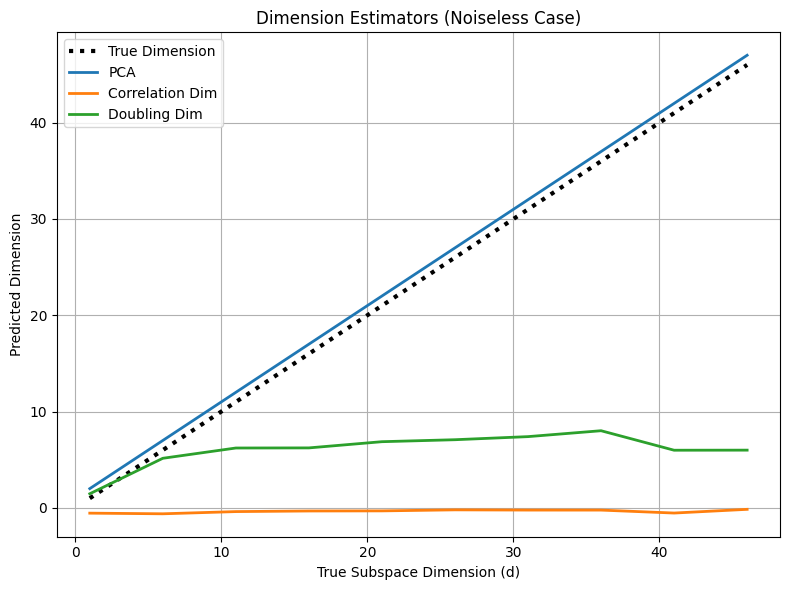

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from functions import synthetic_subspace, correlation_dim, doubling_dim, pca_elbow_estimate

# Sweep over true subspace dimensions
D = 1000
n = 2000
noise_scale = 0.0
d_vals = list(range(1, 51, 5))
pca_vals, corr_vals, dbl_vals = [], [], []

for d in d_vals:
    X = synthetic_subspace(D, d, n, signal_scale=1.0, noise_scale=noise_scale)
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    X_sample = X[:300]  # sample a subset for estimation
    pca_vals.append(pca_elbow_estimate(X_sample))
    corr_vals.append(correlation_dim(X_sample, num_trials=3, sample_size=100))
    dbl_vals.append(doubling_dim(X_sample, num_trials=3, sample_size=10))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(d_vals, d_vals, label="True Dimension", linewidth=3, color="black", linestyle=':')
plt.plot(d_vals, pca_vals, label="PCA", linewidth=2)
plt.plot(d_vals, corr_vals, label="Correlation Dim", linewidth=2)
plt.plot(d_vals, dbl_vals, label="Doubling Dim", linewidth=2)
plt.xlabel("True Subspace Dimension (d)")
plt.ylabel("Predicted Dimension")
plt.title("Dimension Estimators (Noiseless Case)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


100%|██████████| 5/5 [00:15<00:00,  3.09s/it]


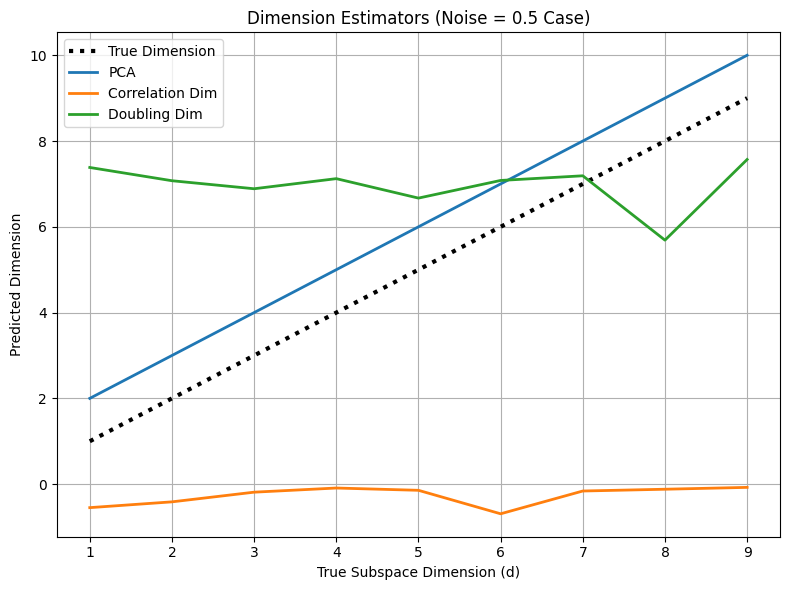

In [2]:
# Sweep over true subspace dimensions
D = 1000
n = 2000
noise_scale = 0.05
d_vals = list(range(1, 10))
pca_vals, corr_vals, dbl_vals = [], [], []

for d in d_vals:
    X = synthetic_subspace(D, d, n, signal_scale=1.0, noise_scale=noise_scale)
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    X_sample = X[:300]  # sample a subset for estimation
    pca_vals.append(pca_elbow_estimate(X_sample))
    corr_vals.append(correlation_dim(X_sample, num_trials=3, sample_size=100))
    dbl_vals.append(doubling_dim(X_sample, num_trials=1, sample_size=5)) #literally takes forever so i am running it with fewer trials :(

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(d_vals, d_vals, label="True Dimension", linewidth=3, color="black", linestyle=':')
plt.plot(d_vals, pca_vals, label="PCA", linewidth=2)
plt.plot(d_vals, corr_vals, label="Correlation Dim", linewidth=2)
plt.plot(d_vals, dbl_vals, label="Doubling Dim", linewidth=2)
plt.xlabel("True Subspace Dimension (d)")
plt.ylabel("Predicted Dimension")
plt.title("Dimension Estimators (Noise = 0.5 Case)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()